In [15]:
# load a .pt textual inversion file and show / manipulate it
import torch
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import numpy as np
import os

1. load a PyTorch tensor from a TI file located in the 'textual_inversions' directory. The tensor is loaded onto the CPU.
2. print the keys of the loaded data, which is expected to be a dictionary, then print the key/value pairs.
3. extract the tensor associated with the key '*' from the dictionary under the 'string_to_param' key.
4. convert the extracted tensor to a NumPy array and detaches it from the GPU. All subsequent ops are performed on this NumPy array.
5. retrieve and print the number of vectors and the shape of the tensor.

In [16]:
# Load the dictionary from the .pt file within 'textual_inversions' directory
# eg : 'textual_inversions\TI_Tron_original.pt'

filename = 'TI_Tron_original.pt'

data = torch.load('textual_inversions/'+filename, map_location='cpu')
print('TI loaded successfully from ',filename)
print('-------')
print(data.keys())
print('-------')
#for each key, print the data
for key in data.keys():
    print('key: ',key,' data[key]: ',data[key])

#extract the tensor from the "string_to_param" key, and create a numpy version of it on CPU

# Extract the tensor associated with the key '*'
tensor = data['string_to_param']['*']

# Convert the tensor to a NumPy array. It's always a good idea to detach the tensor from the GPU
# all operations will be done on the numpy array
np_array = tensor.cpu().detach().numpy()
numvectors = np_array.shape[0] # get number of vectors
print('\nNumber of vectors: ',numvectors,'    Shape of the tensor: ',np_array.shape)

#create several copies of the numpy array
np_smoothed = np_array.copy()
np_mean = np_array.copy()
np_decimated = np_array.copy()
np_divided = np_array.copy()
np_rolled = np_array.copy()

#plus one for plotting original...
np_plotting = np_array.copy()


TI loaded successfully from  TI_Tron_original.pt
-------
dict_keys(['string_to_token', 'string_to_param', 'name', 'step', 'sd_checkpoint', 'sd_checkpoint_name'])
-------
key:  string_to_token  data[key]:  {'*': 265}
key:  string_to_param  data[key]:  {'*': tensor([[ 0.0332,  0.0405,  0.0354,  ...,  0.0685, -0.0129, -0.0338],
        [-0.0588, -0.0188,  0.0036,  ...,  0.0679, -0.0458,  0.0542],
        [ 0.0784, -0.0162,  0.0400,  ...,  0.0390,  0.0686,  0.0756],
        ...,
        [ 0.0364, -0.0542,  0.0208,  ..., -0.0587,  0.0521,  0.0246],
        [ 0.0437, -0.0197, -0.0377,  ...,  0.0301, -0.0330,  0.0273],
        [-0.0385, -0.0180, -0.0414,  ..., -0.0428,  0.0292,  0.0398]],
       requires_grad=True)}
key:  name  data[key]:  Style-TronLegacy-8v-2280
key:  step  data[key]:  2279
key:  sd_checkpoint  data[key]:  81761151
key:  sd_checkpoint_name  data[key]:  v1-5-pruned-emaonly

Number of vectors:  8     Shape of the tensor:  (8, 768)


plot some statistics on the original TI...

Reshaped array to:  (8, 32, 24) for plotting


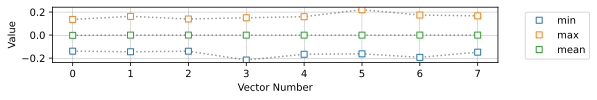

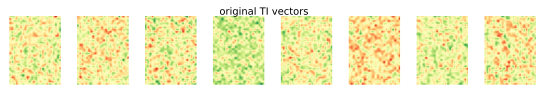

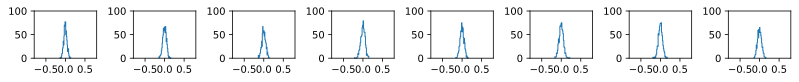

In [17]:
# reshape the numpy array to n x 2D images
# The first dim is number of vectors/tokens used in the TI
# 32x24 is an arbitrary choice, as the original tensor(s) are 768 long (32x24)

np_plotting = np_plotting.reshape(numvectors,32,24)
print('Reshaped array to: ',np_plotting.shape,'for plotting')
# Calculate the min, max, and mean of each 2D image
min_values = np.min(np_plotting, axis=(1,2))
max_values = np.max(np_plotting, axis=(1,2))
mean_values = np.mean(np_plotting, axis=(1,2))

def fn_plot_min_max_mean(min_values, max_values, mean_values):
    # Plot the min, max, and mean values
    plt.figure(figsize=(numvectors, 1))

    # Plot the lines with alpha=0.5
    plt.plot(min_values, color='black', linestyle='dotted', alpha=0.4)
    plt.plot(max_values, color='black', linestyle='dotted', alpha=0.4)
    plt.plot(mean_values, color='black', linestyle='dotted', alpha=0.4)

    # Plot the markers with alpha=1.0
    plt.plot(min_values, 's', markersize=6, markerfacecolor='w', label='min')
    plt.plot(max_values, 's', markersize=6, markerfacecolor='w', label='max')
    plt.plot(mean_values, 's', markersize=6, markerfacecolor='w', label='mean')

    plt.grid(True, which='both', linestyle='--', linewidth=0.2, color='black')
    #plt.title('Min, Max, and Mean Values')
    plt.xlabel('Vector Number')

    # Move the legend outside the chart
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.ylabel('Value')
    plt.show()

fn_plot_min_max_mean(min_values, max_values, mean_values)

#plot grid of n images, using the first dimension of numpy_array
fig, axs = plt.subplots(1, numvectors, figsize=(numvectors*1.2, 1.25))
for i in range(numvectors):
    axs[i].imshow(np_plotting[i], cmap='RdYlGn',interpolation='bilinear')
    axs[i].axis('off')
plt.suptitle('original TI vectors', fontsize=10)
plt.show()

#plot histograms
fig, axs = plt.subplots(1, numvectors, figsize=(numvectors*1.4, 1.25))
for i in range(numvectors):
    axs[i].hist(np_plotting[i].flatten(), bins=30, histtype='step')
    axs[i].set_xlim([-0.8, 0.8])  # Set the x-axis limits
    axs[i].set_ylim([0, 100])  # Set the y-axis limits
plt.tight_layout()
plt.show()

Perform smoothing of all values in each tensor row, using a defined kernel size (eg: 3 or 5 etc)

Plot smoothed vectors. return np_smoothed

smoothing kernel used:  5


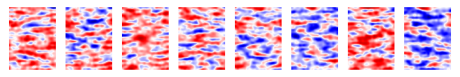

np_smoothed shape:  (8, 768)


In [18]:
# SMOOTHING

#flatten the numpy array
np_smoothed = np_smoothed.flatten()
#print('Flattened array to: ',np_smoothed.shape)

#sm_kernel = 3    # nxn smoothing kernel, can set to *1* to skip smoothing
sm_kernel = int(input("SMOOTHING: Enter kernel size (MUST BE ODD eg '3'), or enter '1' to skip smoothing:"))  # nxn smoothing kernel, can set to *1* to skip smoothing
print('smoothing kernel used: ',sm_kernel)

#apply a 1D smoothing filter to the numpy array
smooth_tmp = np.convolve(np_smoothed, np.ones(sm_kernel)/sm_kernel, mode='full')
#print('length of smoothed array (untrimmed): ',len(smooth_tmp) )
#print('sm_kernel: ',sm_kernel,' sm_kernel//2: ',sm_kernel//2)

#extract the central part of the smoothed array
smooth_tmp = smooth_tmp[sm_kernel//2:len(smooth_tmp)-sm_kernel//2] # use[1:-1] for 3x3 filter, [2:-2] for 5x5 filter. integer round down division used ('//')
#print the length of the smoothed array
#print('length of smoothed, trimmed array: ',len(smooth_tmp) )

smooth_tmp = smooth_tmp.reshape(numvectors,32,24)

#plot a grid of n images using the first dim of numpy_array
fig, axs = plt.subplots(1, numvectors, figsize=(numvectors, 1.5))
for i in range(numvectors):
    axs[i].imshow(smooth_tmp[i], cmap='seismic',interpolation='bicubic')
    axs[i].axis('off')
plt.show()

#reshape the array back to how it was
smooth_tmp = smooth_tmp.reshape(numvectors,-1)
#print('Reshaped array back to: ',smooth_tmp.shape)

np_smoothed = smooth_tmp.copy()
print('np_smoothed shape: ',np_smoothed.shape)


roll_amount amount used:  1


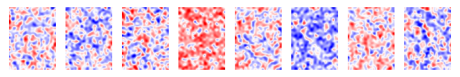

Reshaped array back to:  (8, 768)


In [19]:
# ROLLING

#flatten the numpy array
np_rolled = np_rolled.flatten()
#print('Flattened array to: ',np_smoothed.shape)

roll_amount = int(input("ROLLING: Enter eg '3', or enter '0' to skip rolling (can be +ve or -ve) : "))
print('roll_amount amount used: ',roll_amount)

#roll_amount the numpy array
np_rolled = np.roll(np_rolled, roll_amount)

np_rolled_temp = np_rolled.reshape(numvectors,32,24)

#plot a grid of n images using the first dim of numpy_array
fig, axs = plt.subplots(1, numvectors, figsize=(numvectors, 1.5))
for i in range(numvectors):
    axs[i].imshow(np_rolled_temp[i], cmap='seismic',interpolation='bicubic')
    axs[i].axis('off')
plt.show()

#reshape the array back to how it was
np_rolled = np_rolled.reshape(numvectors,-1)
print('Reshaped array back to: ',np_rolled.shape)



calculate the mean as a single vector, rescaling to account for diminution due to noisy vectors

returns np_mean

In [20]:
# MEAN
# ----
#Stats: min, max, mean, sd

# function to calc and plot stats
def fn_calc_and_plot_stats(tmp_array):
    min_values = []     # create empty lists
    max_values = []
    mean_values = []
    sd_values = []

    for i in range(tmp_array.shape[0]):     # Calc and plot stats for each array/vector
        min_val = np.min(tmp_array[i])
        max_val = np.max(tmp_array[i])
        mean_val = np.mean(tmp_array[i])
        sd_val = np.std(tmp_array[i])

        min_values.append(min_val)         # Append the values to the lists
        max_values.append(max_val)
        mean_values.append(mean_val)
        sd_values.append(sd_val)

        print(f"V {i+1}:  Min={min_val:.2f},  Max={max_val:.2f},  Mean={mean_val:.2f},  SD={sd_val:.2f}")
    meanSD = np.mean(sd_values)
    print(f"Mean SD across all vectors: {meanSD:.4f}")

    # Plot (only if debug = True)
    debug = False
    if debug:
        fig, ax = plt.subplots(figsize=(6, 3))
        bar_width = 0.20      # Define bar width and positions
        positions = np.arange(1, tmp_array.shape[0]+1)
        # Create bar plots
        ax.bar(positions - 1.5*bar_width, min_values, width=bar_width, label='Min')
        ax.bar(positions - 0.5*bar_width, max_values, width=bar_width, label='Max')
        ax.bar(positions + 0.5*bar_width, mean_values, width=bar_width, label='Mean')
        ax.bar(positions + 1.5*bar_width, sd_values, width=bar_width, label='SD')
        ax.set_title('Stats of original TI vectors', fontsize=10)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_axisbelow(True)    # Draw grid behind bars
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    return(meanSD)

meanSD = fn_calc_and_plot_stats(np_mean)       # Call the function

#reshape and take single mean across rows/vectors:

Xmean = np_mean  # Reshape X to 2D array with n rows/vectors
Xmean = np.mean(Xmean, axis=0)     # Calculate average across all rows/vectors
print(Xmean.shape)  # Should print: (768,)

min_val = np.min(Xmean)
max_val = np.max(Xmean)
mean_val = np.mean(Xmean)
sd_val = np.std(Xmean)
print(f"Xmean Array (straight mean):                            Min={min_val:.3f}, Max={max_val:.3f}, Mean={mean_val:.3f}, SD={sd_val:.3f}")

# taking the mean of noisy data results in overall smaller magnitudes for the final vector.
# to adjust for this, scale the mean vector to have the same SD as the (mean of the SDs) of the orig vectors
Xmean = Xmean * meanSD/sd_val

# recalc and show stats
min_val = np.min(Xmean)
max_val = np.max(Xmean)
mean_val = np.mean(Xmean)
sd_val = np.std(Xmean)
print(f"Xmean Array (adjusted to match meanSD of orig vectors): Min={min_val:.3f}, Max={max_val:.3f}, Mean={mean_val:.3f}, SD={sd_val:.3f}")

#reshape the array back to how it was
np_mean = Xmean # Reshape Xmean back to 3D array, assign to np_mean
#reshape to a 1D array
np_mean = np_mean.reshape(1,-1)
print('Reshaped np_mean array back to: ',np_mean.shape)

V 1:  Min=-0.14,  Max=0.14,  Mean=-0.00,  SD=0.04
V 2:  Min=-0.14,  Max=0.16,  Mean=-0.00,  SD=0.05
V 3:  Min=-0.14,  Max=0.14,  Mean=0.00,  SD=0.05
V 4:  Min=-0.22,  Max=0.15,  Mean=-0.00,  SD=0.05
V 5:  Min=-0.17,  Max=0.16,  Mean=-0.00,  SD=0.05
V 6:  Min=-0.16,  Max=0.22,  Mean=-0.00,  SD=0.06
V 7:  Min=-0.19,  Max=0.17,  Mean=0.00,  SD=0.05
V 8:  Min=-0.15,  Max=0.17,  Mean=-0.00,  SD=0.05
Mean SD across all vectors: 0.0505
(768,)
Xmean Array (straight mean):                            Min=-0.093, Max=0.085, Mean=-0.000, SD=0.026
Xmean Array (adjusted to match meanSD of orig vectors): Min=-0.180, Max=0.164, Mean=-0.001, SD=0.050
Reshaped np_mean array back to:  (1, 768)


In [21]:
def fn_divide(X, divisor):
    '''divides the tensor by a scalar value'''
    X = X / divisor
    return X

# DIVIDE
# ------
#divide the tensor by a scalar value
divisor = float(input("Enter the divisor for the tensor: "))
np_divided = fn_divide(np_divided, divisor)
print('TI divided successfully by ',divisor)



TI divided successfully by  2.0


In [22]:
# we now have run different operations on the tensor, and have multiple numpy arrays
#print the shape of each array
print('np_decimated shape: ',np_decimated.shape)
print('np_smoothed shape: ',np_smoothed.shape)
print('np_mean shape: ',np_mean.shape)
print('np_divided shape: ',np_divided.shape)
print('np_rolled shape: ',np_rolled.shape)


np_decimated shape:  (8, 768)
np_smoothed shape:  (8, 768)
np_mean shape:  (1, 768)
np_divided shape:  (8, 768)
np_rolled shape:  (8, 768)


Ask the user to choose between options...

In [23]:
# Ask the user to choose between three options
user_input = input("Choose: '1'-smoothing all vectors, '2'-a single MEAN vector,'3'-all vectors with nth element zeroed, '4'-divide all vectors by a scalar:,'5'-roll all vectors")

if user_input == "1":
    print("You chose Option 1 - retain all vectors, but with SMOOTHING...")
    # convert the numpy array back to tensor, include the "device='cuda:0', requires_grad=True" parameters
    tensor = torch.tensor(np_smoothed, device='cuda:0', requires_grad=True)
    print(tensor.shape)
    data['string_to_param']['*'] = tensor  # store the tensor back in the data dictionary

elif user_input == "2":
    print("You chose Option 2 - condense to a SINGLE (scaled) MEAN vector...")
    tensor = torch.tensor(np_mean, device='cuda:0', requires_grad=True)  
    print(tensor.shape)
    data['string_to_param']['*'] = tensor  # store the tensor back in the data dictionary

elif user_input == "3":
    print("You chose Option 3 - retain all vectors, but decimated with zeros...")
    tensor = torch.tensor(np_decimated, device='cuda:0', requires_grad=True) 
    print(tensor.shape)
    data['string_to_param']['*'] = tensor  # store the tensor back in the data dictionary

elif user_input == "4":
    print("You chose Option 4 - retain all vectors, but divided by a scalar...")
    tensor = torch.tensor(np_divided, device='cuda:0', requires_grad=True) 
    print(tensor.shape)
    data['string_to_param']['*'] = tensor  # store the tensor back in the data dictionary

elif user_input == "5":
    print("You chose Option 5 - retain all vectors, but ROLLED...")
    tensor = torch.tensor(np_rolled, device='cuda:0', requires_grad=True) 
    print(tensor.shape)
    data['string_to_param']['*'] = tensor  # store the tensor back in the data dictionary

else:
    print("Invalid choice. Please enter '1','2','3', '4' or '5'...")


You chose Option 5 - retain all vectors, but ROLLED...
torch.Size([8, 768])


SAVE the TI

In [24]:

# Ask the user for a filename
filename = input("Please enter a filename: ('_sm<kernel>.pt' / '_mean.pt' / 'dec<n><T/F>' will be appended to the submitted filename)")

if user_input == "1":
    filename = filename + "_sm" + str(sm_kernel) + ".pt"
elif user_input == "2":
    filename = filename + "_mean.pt"
elif user_input == "3":
    filename = filename + "_dec" + str(mask_length) + str(every_nth) + ".pt"
elif user_input == "4":
    filename = filename + "_div" + str(divisor) + ".pt"
elif user_input == "5":
    filename = filename + "_roll" + str(roll_amount) + ".pt"

# Specify the directory path
directory = "textual_inversions"

# Create the directory if it doesn't exist
if not os.path.exists(directory):
    os.makedirs(directory)

# Save the file to the directory
filepath = os.path.join(directory, filename)
torch.save(data, filepath)

print(f"The file '{filename}' has been saved to the '{directory}' directory.")


The file 'myrolledTRON_roll1.pt' has been saved to the 'textual_inversions' directory.
